In [1]:
import pandas as pd
from scipy.io import mmread
import scipy.sparse
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ranksums
from scipy import stats

In [2]:
scroot = '/work/users/k/r/kritis/single_cell/PRJNA679579'

In [3]:
X = mmread(f"{scroot}/GSE161824_A549_TP53.processed.matrix.mtx").tocsr()

In [4]:
# Load gene names and barcodes
genes = pd.read_csv(f"{scroot}/GSE161824_A549_TP53.processed.genes.csv", header=None)
barcodes = pd.read_csv(f"{scroot}/GSE161824_A549_TP53.processed.cells.csv", header=None)

In [5]:
import anndata as ad
adata = ad.AnnData(X)
adata.var_names = genes[0].values  # column 1 = gene symbols
adata.obs_names = barcodes[0].values

In [6]:
# Calculate basic QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Filter cells: min genes, max counts, max % mitochondrial
adata = adata[adata.obs['n_genes_by_counts'] > 200, :]
adata = adata[adata.obs['total_counts'] < 25000, :]

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [7]:
sc.pp.filter_genes(adata, min_cells=10)

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:283: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [8]:
barcodes_mut = pd.read_csv('/work/users/k/r/kritis/database_analysis/TP53_example/HES2_barcodes.csv')

In [9]:
barcode_list = barcodes_mut['cell_barcode'].tolist()

In [10]:
adata.obs['mut'] = adata.obs_names.isin(barcode_list)
# Optional: make it clearer
adata.obs['mut'] = adata.obs['mut'].map({True: 'Target', False: 'Other'})

In [11]:
adata_target = adata[adata.obs['mut'] == 'Target'].copy()
adata_other = adata[adata.obs['mut'] == 'Other'].copy()

In [12]:
adata.obs['mut'].value_counts()

mut
Other     64248
Target    21530
Name: count, dtype: int64

In [13]:
sc.tl.rank_genes_groups(adata, groupby='mut', method='wilcoxon', 
                        groups=['Target'], reference='Other')

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


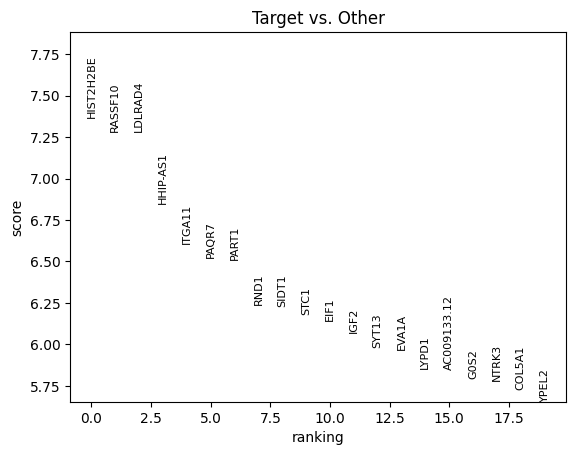

,Target_names,Target_scores,Target_logfoldchanges,Target_pvals_adj
0,HIST2H2BE,7.368357,NaN,3.020538e-11
1,RASSF10,7.282773,NaN,4.523190e-11
2,LDLRAD4,7.280499,-1.602722,4.523190e-11
3,HHIP-AS1,6.848704,NaN,8.292260e-10
4,ITGA11,6.609318,-1.747571,3.938175e-09


In [14]:
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

# Extract as a DataFrame
import pandas as pd
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
de_genes = pd.DataFrame(
    {group + '_' + key: result[key][group]
     for group in groups for key in ['names', 'scores', 'logfoldchanges', 'pvals_adj']}
)
de_genes.head()

In [15]:
de2 = de_genes.dropna().sort_values(by=['Target_logfoldchanges'],ascending=False)

In [16]:
de2

,Target_names,Target_scores,Target_logfoldchanges,Target_pvals_adj
556,SLC22A18,0.412045,10.501164,0.817821
1187,CAST,-3.977163,8.848053,0.000783
242,HSPA8,2.008953,8.276462,0.132975
603,B2M,0.229304,7.461351,0.906793
1151,RTN4RL2,-3.165543,6.921747,0.009473
...,...,...,...,...
639,MAFK,0.117908,-5.606192,0.954463
487,RNF212,0.710409,-5.880363,0.656628
463,CLU,0.819597,-6.227500,0.598853
39,PXDN,4.667977,-6.909007,0.000059


In [17]:
print(*de2.head(50)['Target_names'].tolist())

SLC22A18 CAST HSPA8 B2M RTN4RL2 C19orf81 KRT18 STOM BTBD11 LYPD1 NUCB2 APOC1 SLC40A1 MTHFD2 PTRF KRCC1 SDPR CHP1 CYBA LINC01588 SKIL LINC01220 EPS8 PFKP HMGB2 KRT8 MAGED2 TMEM120B RNF19A IFI27 PSAT1 IGFBP6 GREM1 HGD ANXA4 SLC26A2 HIST1H1B INO80C HERPUD1 BCL2L1 NPTX1 RP11-51J9.5 PDZK1IP1 FSTL1 CP C15orf48 LMNA LINC00473 CTGF ESAM


In [18]:
df = de2.copy()

In [19]:
genes = pd.read_csv('/work/users/k/r/kritis/single_cell/PRJNA679579/TP53_HES2_example/genelist.csv')

In [20]:
gene_list = genes['0'].tolist()

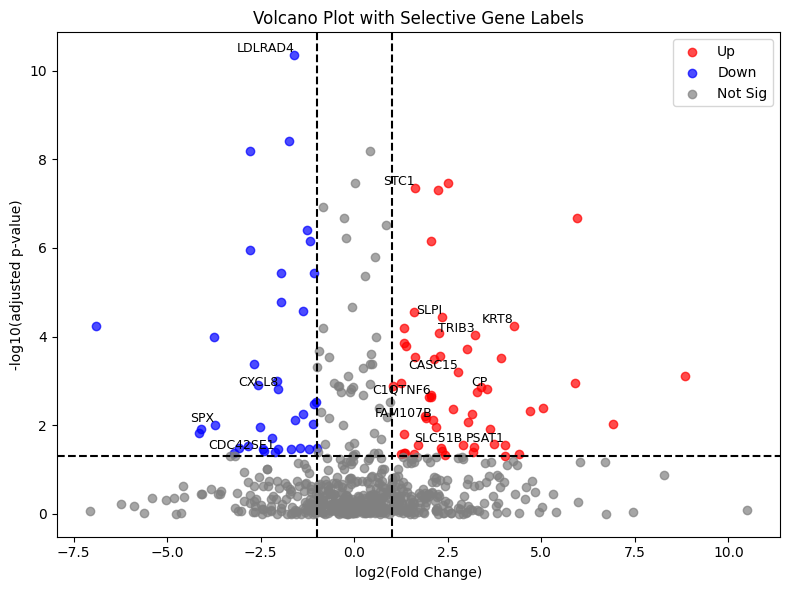

In [21]:
fc_thresh = 1
pval_thresh = 0.05

# Create -log10(padj)
df['neg_log10_padj'] = -np.log10(df['Target_pvals_adj'])

# Label significance
df['significant'] = 'Not Sig'
df.loc[(df['Target_pvals_adj'] < pval_thresh) & (df['Target_logfoldchanges'] > fc_thresh), 'significant'] = 'Up'
df.loc[(df['Target_pvals_adj'] < pval_thresh) & (df['Target_logfoldchanges'] < -fc_thresh), 'significant'] = 'Down'

# Plot
plt.figure(figsize=(8, 6))
colors = {'Up': 'red', 'Down': 'blue', 'Not Sig': 'gray'}

for sig, color in colors.items():
    subset = df[df['significant'] == sig]
    plt.scatter(subset['Target_logfoldchanges'], subset['neg_log10_padj'], c=color, label=sig, alpha=0.7)

# Filter genes to label: in list AND pass thresholds
label_df = df[
    (df['Target_names'].isin(gene_list)) &
    (df['Target_pvals_adj'] < pval_thresh) &
    (abs(df['Target_logfoldchanges']) > fc_thresh)
]

# Add labels
for _, row in label_df.iterrows():
    plt.text(row['Target_logfoldchanges'], row['neg_log10_padj'], row['Target_names'],
             fontsize=9, ha='right', va='bottom', color='black')

# Threshold lines
plt.axhline(-np.log10(pval_thresh), color='black', linestyle='--')
plt.axvline(fc_thresh, color='black', linestyle='--')
plt.axvline(-fc_thresh, color='black', linestyle='--')

plt.xlabel("log2(Fold Change)")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano Plot with Selective Gene Labels")
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
de2 = de_genes.dropna().sort_values('Target_logfoldchanges').reset_index(drop=True)

In [52]:
de2[de2['Target_names']=='ADM']

,Target_names,Target_scores,Target_logfoldchanges,Target_pvals_adj
456,ADM,-0.358826,1.276977,0.839794
